In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from supabase import create_client
from dotenv import load_dotenv
import os

load_dotenv()
supabase = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_KEY"))

jobs = pd.DataFrame(supabase.table("job_postings").select("*").execute().data)
mbie = pd.DataFrame(supabase.table("mbie_monthly").select("*").execute().data)

print(f"Jobs: {jobs.shape}, MBIE: {mbie.shape}")
jobs.head()

Jobs: (92, 14), MBIE: (225, 6)


,id,title,company,location,salary_min,salary_max,category,contract_type,date_posted,description,url,keyword,source,scraped_at
0,7,Senior Data Analyst,Vector Limited,"Auckland, North Island",NaN,NaN,IT Jobs,None,2026-02-27,"Job Description Powered by Data At Vector, we’...",https://www.adzuna.co.nz/details/5647008180?ut...,data analyst,adzuna,2026-03-15T23:58:56.137897
1,9,"Programme Lead (Loyalty), VCA Implementation S...",Visa,"Auckland, North Island",NaN,NaN,IT Jobs,None,2026-02-26,Job Description Team Summary Visa Consulting &...,https://www.adzuna.co.nz/details/5645859276?ut...,data analyst,adzuna,2026-03-15T23:58:56.137908
2,31,Business Intelligence Analyst - Clinics,University of Auckland,"Auckland, North Island",NaN,NaN,IT Jobs,None,2026-02-27,Job Description Advanced data analytics and re...,https://www.adzuna.co.nz/details/5647008193?ut...,business analyst,adzuna,2026-03-15T23:58:59.800803
3,40,Technical Business Analyst,Intellihub,"Auckland, North Island",NaN,NaN,IT Jobs,None,2026-02-13,Job Description The Customer Data & Analytics ...,https://www.adzuna.co.nz/details/5626305941?ut...,business analyst,adzuna,2026-03-15T23:58:59.800871
4,46,Business Analyst,Robert Half,"Auckland, North Island",135000.0,145000.0,IT Jobs,None,2026-01-16,The Company Leading organisation that provides...,https://www.adzuna.co.nz/details/5586346449?ut...,business analyst,adzuna,2026-03-15T23:58:59.800906


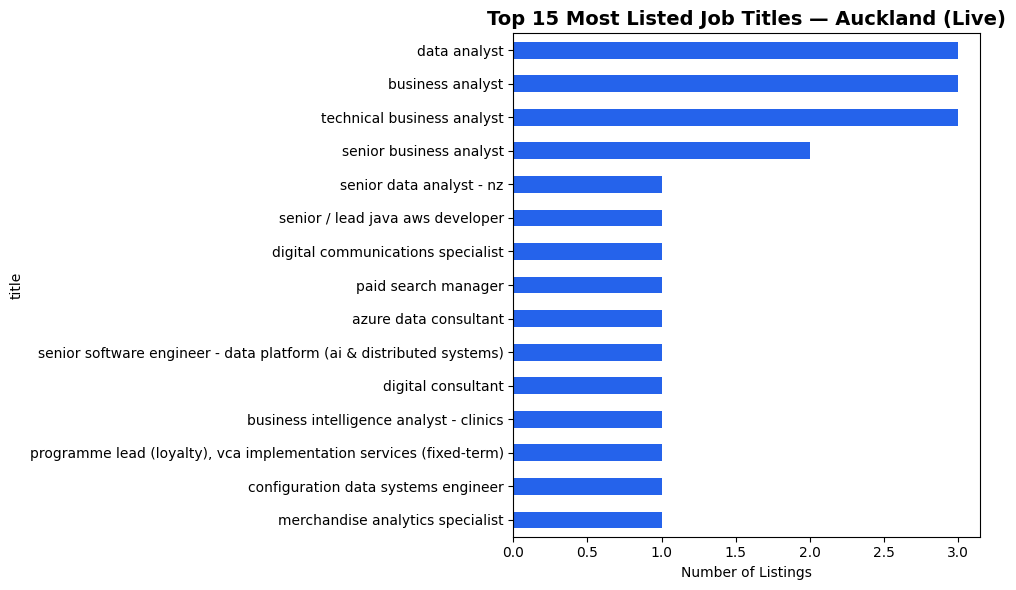

In [5]:
import os
os.makedirs(r"D:\Users\Public\Documents\Project_development\auckland-job-tracker\data", exist_ok=True)
os.chdir(r"D:\Users\Public\Documents\Project_development\auckland-job-tracker")
top_titles = (
    jobs["title"]
    .str.lower()
    .str.strip()
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_titles.sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Top 15 Most Listed Job Titles — Auckland (Live)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Listings")
plt.tight_layout()
plt.savefig("data/top_titles.png", dpi=150)
plt.show()

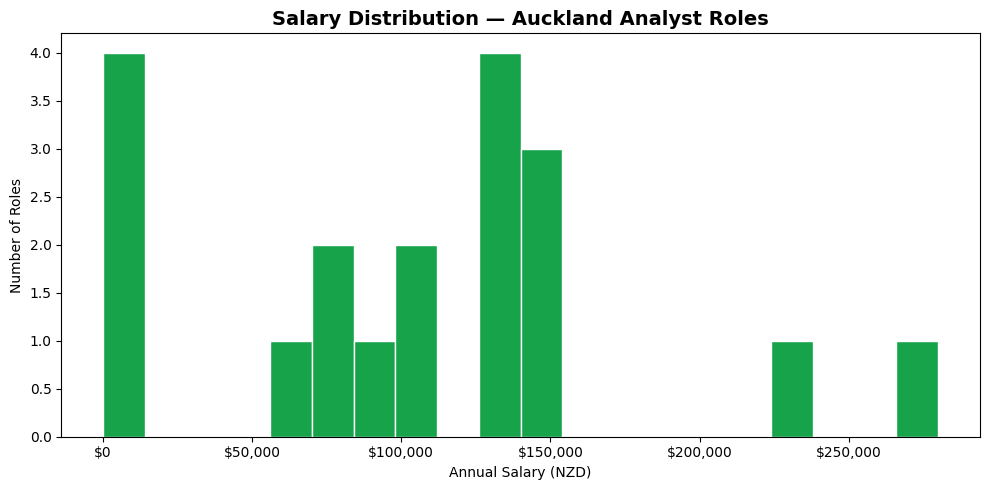


Roles with salary data: 19 / 92
Min: $50
Max: $280,000
Median: $110,000


In [6]:
salary_df = jobs[jobs["salary_min"].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(salary_df["salary_min"], bins=20, color="#16a34a", edgecolor="white")
ax.set_title("Salary Distribution — Auckland Analyst Roles", fontsize=14, fontweight="bold")
ax.set_xlabel("Annual Salary (NZD)")
ax.set_ylabel("Number of Roles")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("data/salary_dist.png", dpi=150)
plt.show()

print(f"\nRoles with salary data: {len(salary_df)} / {len(jobs)}")
print(f"Min: ${salary_df['salary_min'].min():,.0f}")
print(f"Max: ${salary_df['salary_min'].max():,.0f}")
print(f"Median: ${salary_df['salary_min'].median():,.0f}")

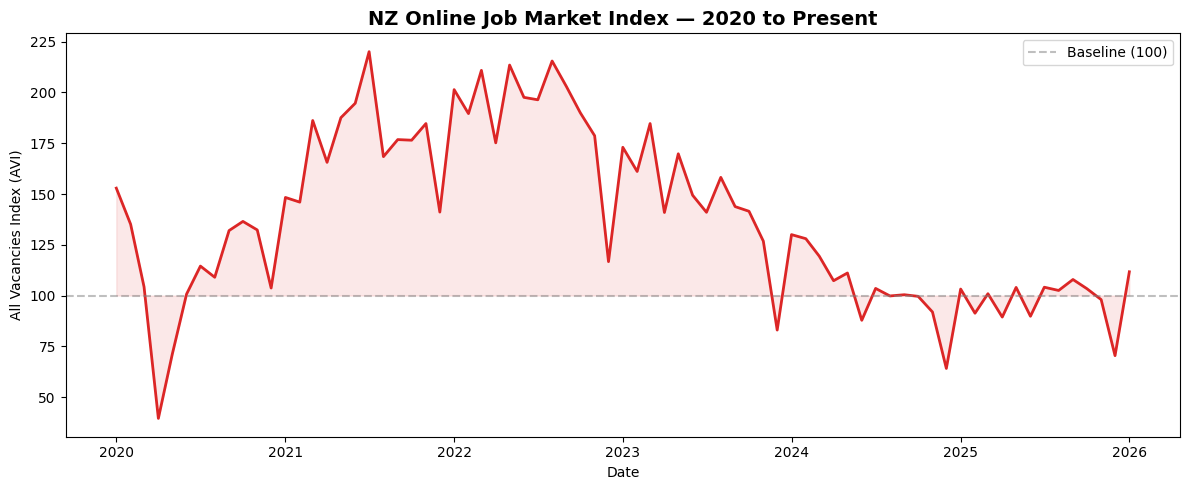

In [7]:
mbie["actual_date"] = pd.to_datetime(mbie["actual_date"])
mbie_recent = mbie[mbie["actual_date"] >= "2020-01-01"].sort_values("actual_date").copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mbie_recent["actual_date"], mbie_recent["totals"], color="#dc2626", linewidth=2)
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5, label="Baseline (100)")
ax.fill_between(mbie_recent["actual_date"], mbie_recent["totals"], 100,
                alpha=0.1, color="#dc2626")
ax.set_title("NZ Online Job Market Index — 2020 to Present", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("All Vacancies Index (AVI)")
ax.legend()
plt.tight_layout()
plt.savefig("data/market_trend.png", dpi=150)
plt.show()

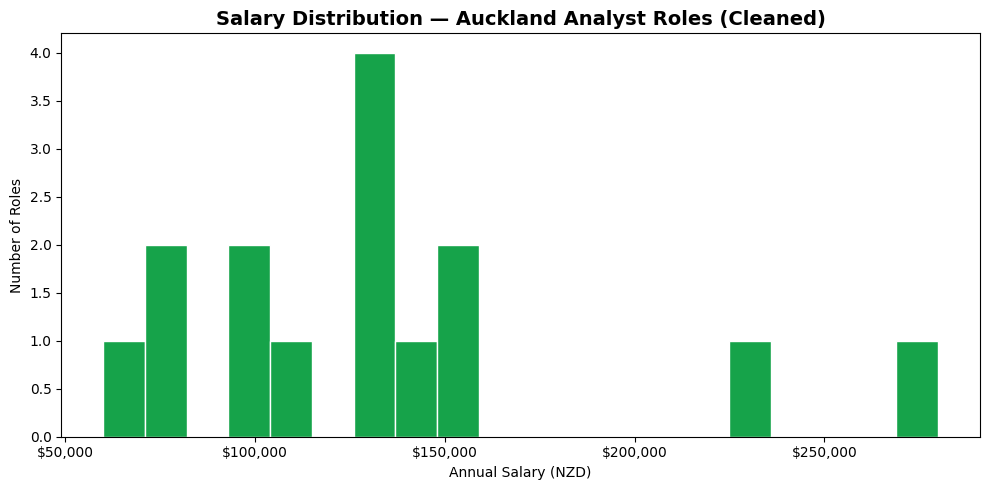

Roles with valid salary data: 15 / 92
Min:    $60,000
Max:    $280,000
Median: $130,000
Mean:   $133,151

── MEDIAN SALARY BY SEARCH KEYWORD ──
keyword
finance analyst     $228,800
business analyst    $132,500
power bi            $130,000
data analyst         $92,557
Name: salary_min, dtype: object


In [8]:
# Filter out clearly wrong salaries (anything under $30,000 is not an annual NZ salary)
salary_df = jobs[
    (jobs["salary_min"].notna()) & 
    (jobs["salary_min"] >= 30000)
].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(salary_df["salary_min"], bins=20, color="#16a34a", edgecolor="white")
ax.set_title("Salary Distribution — Auckland Analyst Roles (Cleaned)", fontsize=14, fontweight="bold")
ax.set_xlabel("Annual Salary (NZD)")
ax.set_ylabel("Number of Roles")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig(r"D:\Users\Public\Documents\Project_development\auckland-job-tracker\data\salary_dist_clean.png", dpi=150)
plt.show()

print(f"Roles with valid salary data: {len(salary_df)} / {len(jobs)}")
print(f"Min:    ${salary_df['salary_min'].min():,.0f}")
print(f"Max:    ${salary_df['salary_min'].max():,.0f}")
print(f"Median: ${salary_df['salary_min'].median():,.0f}")
print(f"Mean:   ${salary_df['salary_min'].mean():,.0f}")

# Salary by keyword
print("\n── MEDIAN SALARY BY SEARCH KEYWORD ──")
print(
    salary_df.groupby("keyword")["salary_min"]
    .median()
    .sort_values(ascending=False)
    .apply(lambda x: f"${x:,.0f}")
)

In [9]:
import re
from collections import Counter

# Define skill keywords to scan for
SKILLS = {
    "sql": r"\bsql\b",
    "python": r"\bpython\b",
    "power bi": r"power bi",
    "excel": r"\bexcel\b",
    "tableau": r"\btableau\b",
    "r programming": r"\br\b",
    "machine learning": r"machine learning",
    "statistics": r"\bstatistics\b",
    "data warehouse": r"data warehouse",
    "etl": r"\betl\b",
    "azure": r"\bazure\b",
    "aws": r"\baws\b",
    "google cloud": r"google cloud",
    "spark": r"\bspark\b",
    "databricks": r"\bdatabricks\b",
    "snowflake": r"\bsnowflake\b",
    "dbt": r"\bdbt\b",
    "airflow": r"\bairflow\b",
    "git": r"\bgit\b",
    "api": r"\bapi\b",
    "communication": r"\bcommunication\b",
    "stakeholder": r"\bstakeholder\b",
    "agile": r"\bagile\b",
    "jira": r"\bjira\b",
    "finance": r"\bfinance\b",
    "accounting": r"\baccounting\b",
    "forecasting": r"\bforecasting\b",
    "budgeting": r"\bbudgeting\b",
    "powerpoint": r"\bpowerpoint\b",
    "sharepoint": r"\bsharepoint\b",
}

def extract_skills(text: str) -> list:
    if not isinstance(text, str):
        return []
    text = text.lower()
    return [skill for skill, pattern in SKILLS.items() if re.search(pattern, text)]

jobs["skills_found"] = jobs["description"].apply(extract_skills)

all_skills = [s for sublist in jobs["skills_found"] for s in sublist]
skill_counts = Counter(all_skills)

skill_df = pd.DataFrame(skill_counts.items(), columns=["skill", "count"])
skill_df = skill_df.sort_values("count", ascending=False).reset_index(drop=True)

print("── TOP SKILLS IN DEMAND (FIXED) ──")
print(skill_df.to_string(index=False))

── TOP SKILLS IN DEMAND (FIXED) ──
        skill  count
    snowflake      3
     power bi      3
      finance      2
r programming      2
          sql      2
       python      2
          aws      1
communication      1
        excel      1
        spark      1
          etl      1
    budgeting      1
        azure      1
          dbt      1
      airflow      1
  stakeholder      1
 google cloud      1


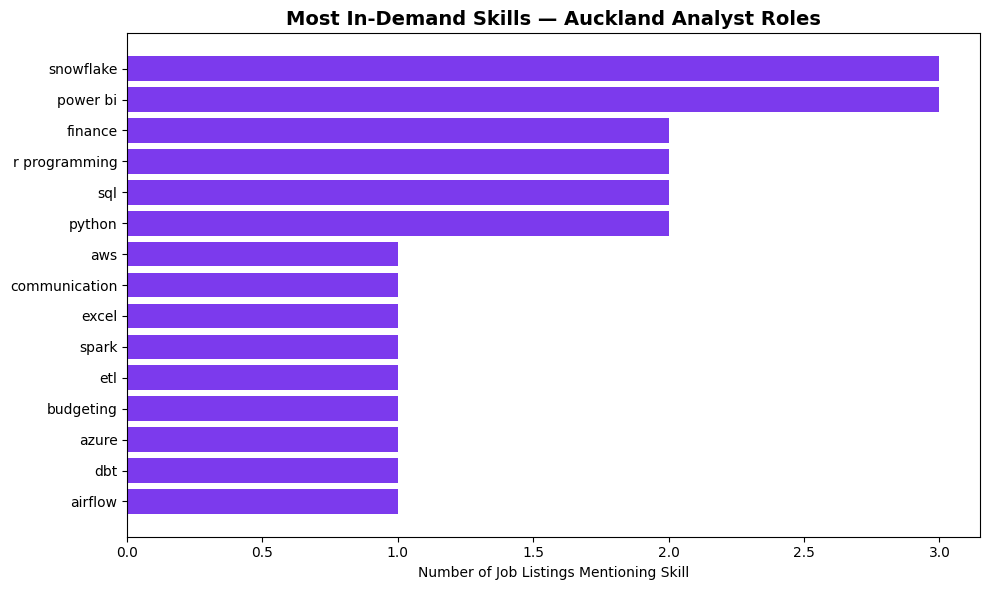

In [10]:
top_skills = skill_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_skills["skill"], top_skills["count"], color="#7c3aed")
ax.set_title("Most In-Demand Skills — Auckland Analyst Roles", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Job Listings Mentioning Skill")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(r"D:\Users\Public\Documents\Project_development\auckland-job-tracker\data\top_skills.png", dpi=150)
plt.show()

In [11]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_absolute_error
import numpy as np

# Use only rows with valid salary
model_df = jobs[jobs["salary_min"] >= 30000].copy()

# Encode skills as binary features
mlb = MultiLabelBinarizer()
skill_matrix = mlb.fit_transform(model_df["skills_found"])
skill_features = pd.DataFrame(skill_matrix, columns=mlb.classes_, index=model_df.index)

X = skill_features
y = model_df["salary_min"]

# Train model (small dataset — no train/test split, we acknowledge this limitation)
model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)
mae = mean_absolute_error(y, predictions)

print(f"Model trained on {len(y)} listings with salary data")
print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"\n── SALARY IMPACT PER SKILL ──")

coef_df = pd.DataFrame({
    "skill": mlb.classes_,
    "salary_impact": model.coef_
}).sort_values("salary_impact", ascending=False)

print(coef_df[coef_df["salary_impact"] != 0].to_string(index=False))

Model trained on 15 listings with salary data
Mean Absolute Error: $11,250

── SALARY IMPACT PER SKILL ──
        skill  salary_impact
    snowflake       161875.0
      finance       110675.0
    budgeting        31875.0
r programming        26875.0
        excel       -21505.5
          sql       -21505.5
          etl       -24768.0
     power bi       -38125.0


In [15]:
# My actual skills
my_skills = ["sql", "python", "power bi", "excel", "finance", "forecasting"]

# Encode your skills using the same binarizer
your_vector = mlb.transform([my_skills])
predicted_salary = model.predict(your_vector)[0]

print("── MY PROFILE ──")
print(f"Skills: {my_skills}")
print(f"Predicted salary range: ${predicted_salary:,.0f} — ${predicted_salary * 1.15:,.0f}")
print(f"\nSkills you have that are in demand:")
for s in my_skills:
    if s in skill_df["skill"].values:
        count = skill_df[skill_df["skill"] == s]["count"].values[0]
        print(f"  {s:20} mentioned in {count} listings")

print(f"\nHigh-value skills to add next:")
missing = coef_df[
    (~coef_df["skill"].isin(my_skills)) & 
    (coef_df["salary_impact"] > 0)
].head(5)
print(missing[["skill", "salary_impact"]].to_string(index=False))

── MY PROFILE ──
Skills: ['sql', 'python', 'power bi', 'excel', 'finance', 'forecasting']
Predicted salary range: $147,664 — $169,814

Skills you have that are in demand:
  sql                  mentioned in 2 listings
  python               mentioned in 2 listings
  power bi             mentioned in 3 listings
  excel                mentioned in 1 listings
  finance              mentioned in 2 listings

High-value skills to add next:
        skill  salary_impact
    snowflake       161875.0
    budgeting        31875.0
r programming        26875.0


D:\Users\Public\Documents\Project_development\auckland-job-tracker\venv\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['forecasting', 'python'] will be ignored
  warnings.warn(
D:\Users\Public\Documents\Project_development\auckland-job-tracker\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
